In [9]:
# ===============================
# 1. IMPORTS
# ===============================
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer

In [10]:
# ===============================
# 2. LOAD DATA
# ===============================
df = pd.read_csv("cleaned_reviews.csv")

In [11]:
# ===============================
# 3. SPELLING CORRECTION
# ===============================
import pkg_resources
from symspellpy import SymSpell

sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)

dictionary_path = pkg_resources.resource_filename(
    "symspellpy", "frequency_dictionary_en_82_765.txt"
)
sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)

def fast_correct(text):
    if not isinstance(text, str):
        return ""
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

df['corrected_en'] = df['clean_avis_en'].apply(fast_correct)

In [12]:
# ===============================
# 4. TEXT CLEANING
# ===============================
def clean_text(text):
    text = str(text).lower()
    
    # remove repeated letters (e.g., aaaaaaaa)
    text = re.sub(r'(.)\1{3,}', '', text)
    
    # remove punctuation & numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

df['clean_final'] = df['corrected_en'].apply(clean_text)

In [13]:
# ===============================
# 5. REMOVE EMPTY ROWS
# ===============================
df = df[df['clean_final'].str.strip() != ""]

In [14]:
# ===============================
# 6. N-GRAM EXTRACTION
# ===============================
vectorizer = CountVectorizer(
    ngram_range=(1,2),      # unigrams + bigrams
    stop_words='english',
    min_df=5                # remove rare words (VERY IMPORTANT)
)

X = vectorizer.fit_transform(df['clean_final'])

In [15]:
# ===============================
# 7. TOP WORDS / N-GRAMS
# ===============================
import numpy as np

sum_words = X.sum(axis=0)

words_freq = [
    (word, sum_words[0, idx]) 
    for word, idx in vectorizer.vocabulary_.items()
]

# sort by frequency
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# display top 20
print("\nTop 20 words / n-grams:\n")
for word, freq in words_freq[:20]:
    print(f"{word}: {freq}")


Top 20 words / n-grams:

insurance: 17828
service: 9342
satisfied: 8220
contract: 7002
price: 6721
years: 5793
good: 5392
customer: 5045
prices: 4750
time: 4073
vehicle: 4061
phone: 3930
recommend: 3920
car: 3878
months: 3850
year: 3784
mutual: 3529
file: 3449
thank: 3263
pay: 3136


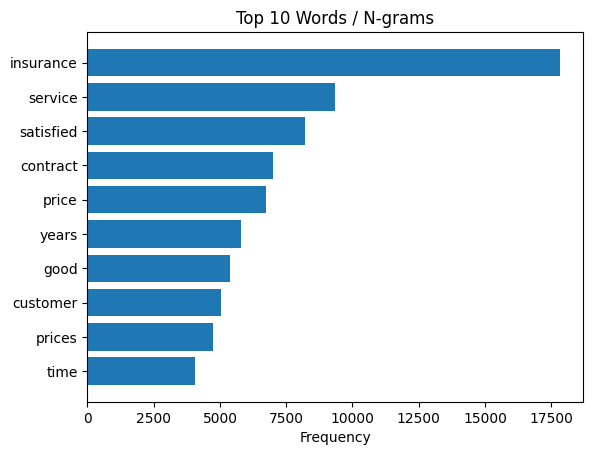

In [16]:
import matplotlib.pyplot as plt

top_words = words_freq[:10]
words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

plt.figure()
plt.barh(words, counts)
plt.gca().invert_yaxis()
plt.title("Top 10 Words / N-grams")
plt.xlabel("Frequency")
plt.show()

In [17]:
# ===============================
# 8. SAVE RESULTS
# ===============================
df.to_csv("final_cleaned_reviews.csv", index=False)

print("\n✅ File saved: final_cleaned_reviews.csv")


✅ File saved: final_cleaned_reviews.csv


In [20]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    max_df=0.9,
    min_df=5,
    stop_words='english'
)

X = vectorizer.fit_transform(df['clean_final'])

In [21]:
# TOPIC MODELING
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [22]:
def display_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\n🔹 Topic {topic_idx+1}:")
        print(" | ".join([
            feature_names[i]
            for i in topic.argsort()[:-n_top_words - 1:-1]
        ]))

feature_names = vectorizer.get_feature_names_out()
display_topics(lda, feature_names, 10)


🔹 Topic 1:
satisfied | service | insurance | price | prices | recommend | good | fast | simple | customer

🔹 Topic 2:
insurance | vehicle | years | car | expert | accident | disaster | responsible | mail | home

🔹 Topic 3:
insurance | year | contract | years | mutual | euros | pay | increase | price | termination

🔹 Topic 4:
satisfied | thank | phone | good | contract | advisor | information | time | quote | services

🔹 Topic 5:
months | service | file | contract | email | insurance | phone | sent | customer | time


In [23]:
# WORD2VEC training
from gensim.models import Word2Vec

sentences = df['corrected_en'].dropna().apply(str.split)

In [24]:
w2v_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4
)

In [25]:
print(w2v_model.wv.most_similar("service", topn=10))

[('relations', 0.7501724362373352), ('area', 0.7164052128791809), ('department', 0.670927107334137), ('relationship', 0.6315407752990723), ('services', 0.624876081943512), ('directing', 0.6133305430412292), ('advisers', 0.5650538206100464), ('platform', 0.5301113724708557), ('communication', 0.5292867422103882), ('generally', 0.5255882143974304)]


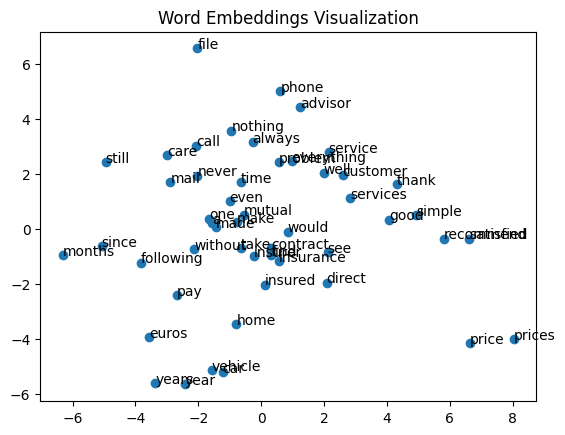

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = list(w2v_model.wv.index_to_key[:50])
vectors = [w2v_model.wv[word] for word in words]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure()
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

plt.title("Word Embeddings Visualization")
plt.show()

In [28]:
from sklearn.metrics.pairwise import cosine_similarity

word1 = w2v_model.wv['service']
word2 = w2v_model.wv['support']

similarity = cosine_similarity([word1], [word2])
print("Cosine similarity:", similarity[0][0])

Cosine similarity: 0.30542305


In [29]:
import numpy as np

def get_sentence_vector(sentence):
    words = sentence.split()
    vectors = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    
    if len(vectors) == 0:
        return np.zeros(w2v_model.vector_size)
    
    return np.mean(vectors, axis=0)

# Precompute vectors
df['vector'] = df['clean_final'].apply(get_sentence_vector)

In [30]:
def semantic_search(query, top_n=5):
    query_vec = get_sentence_vector(query)
    
    similarities = df['vector'].apply(
        lambda x: cosine_similarity([query_vec], [x])[0][0]
    )
    
    top_indices = similarities.nlargest(top_n).index
    
    return df.loc[top_indices, ['clean_final']]

# Example
results = semantic_search("bad customer service")
print(results)

                              clean_final
3771                 bad customer service
5978                 bad customer service
26090  customer service simply deplorable
2072          deplorable customer service
5674          deplorable customer service


In [31]:
import gensim.downloader as api

glove = api.load("glove-wiki-gigaword-100")

print(glove.most_similar("insurance"))

[==================================================] 100.0% 128.1/128.1MB downloaded
[('insurers', 0.8099266886711121), ('pension', 0.7751834988594055), ('premiums', 0.7553386092185974), ('care', 0.7154489159584045), ('insurer', 0.7120343446731567), ('savings', 0.7096748948097229), ('credit', 0.6883228421211243), ('health', 0.6881067752838135), ('payments', 0.6837214827537537), ('pay', 0.6818075180053711)]
